In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import datetime
from pathlib import Path

from rasterio.plot import plotting_extent
from matplotlib.colors import ListedColormap

Min: -10.689999999999998
Max: 70.51000000000005
Total pixels: 7438848
NaN count: 2912340 ( 39.15 %)


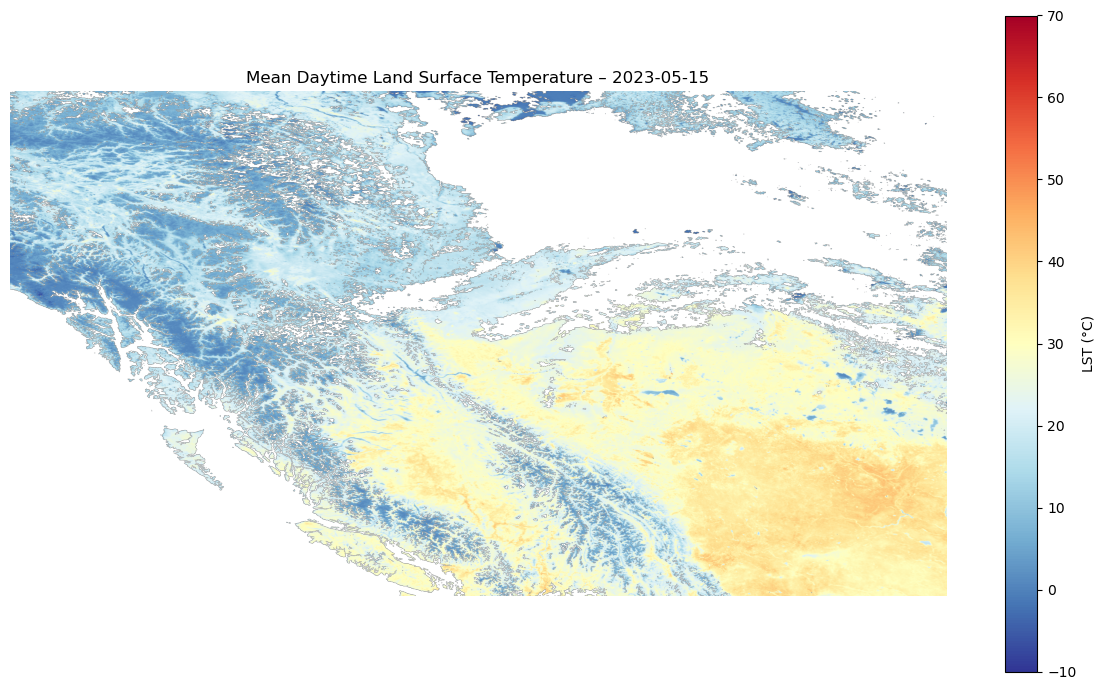

In [7]:
# Temperature
with rasterio.open("/Volumes/Scratch/jchen/anemoi-project/meanDaytimeLST_colorized_2023-05-15.tif") as src:
    band = src.read(1).astype(float)

    print('Min:', np.nanmin(band))
    print('Max:', np.nanmax(band))
    print('Total pixels:', band.size)
    nan_ratio = np.round(np.sum(np.isnan(band)) / band.size * 100, 2)
    print('NaN count:', np.sum(np.isnan(band)), '(', nan_ratio, '%)')

    band[band == 0] = np.nan  # mask any zero-nodata

plt.figure(figsize=(12, 7))
plt.imshow(band, cmap='RdYlBu_r', vmin=-10, vmax=70)
plt.colorbar(label='LST (°C)')
plt.title('Mean Daytime Land Surface Temperature – 2023-05-15')
plt.axis('off')
plt.tight_layout()
plt.show()

Min: -23.009999999999962
Max: 41.950000000000045
Total pixels: 7438848
NaN count: 3788546 ( 50.93 %)


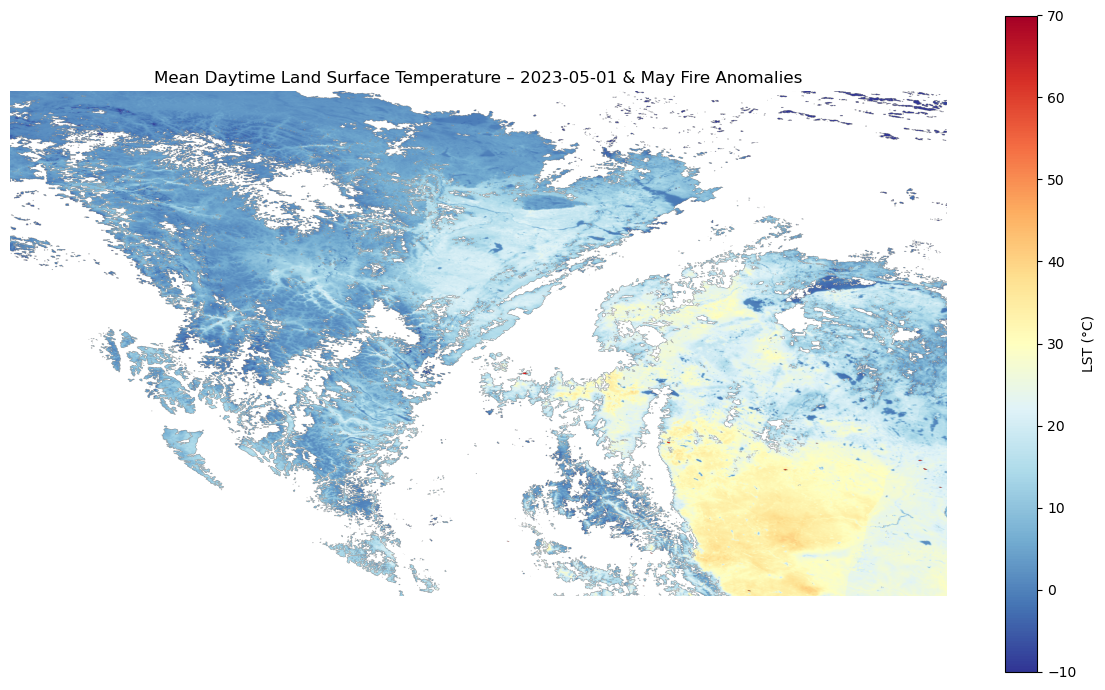

In [8]:
# I JUST WANT TO GENERATE IMAGES FOR ONE DAY

one_day = datetime.datetime(2023, 5, 1)

# Temperature (mean daytime LST)
with rasterio.open(f"/Volumes/Scratch/jchen/GEE/meanDaytimeLST_colorized_{one_day.strftime('%Y-%m-%d')}.tif") as src:
    temp_band = src.read(1).astype(float)
    temp_band_extent = plotting_extent(src)

    print('Min:', np.nanmin(temp_band))
    print('Max:', np.nanmax(temp_band))            
    print('Total pixels:', temp_band.size)
    nan_ratio = np.round(np.sum(np.isnan(temp_band)) / temp_band.size * 100, 2)
    print('NaN count:', np.sum(np.isnan(temp_band)), '(', nan_ratio, '%)')

    temp_band[temp_band == 0] = np.nan  # mask any zero-nodata

# Fire and Thermal Anomalies (one value per pixel, 0 for no fire, 1 for fire)
# FIRMS dataset is flagged as not science quality for quantitavtive analysis:
# https://developers.google.com/earth-engine/datasets/catalog/FIRMS
with rasterio.open(f"/Volumes/Scratch/jchen/GEE/Fire_and_Thermal_Anomalies_max_{one_day.strftime('%Y-%m-%d')}.tif") as src:
    fire = src.read(1).astype(float)
    fire_extent = plotting_extent(src)

    fire[fire == 0] = np.nan  # mask any zero-nodata
    fire_mask = np.where(np.isnan(fire), np.nan, 1)  # create a mask where fire is present

# Plotting
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(temp_band, cmap='RdYlBu_r', vmin=-10, vmax=70)
plt.colorbar(im, ax=ax, label='LST (°C)')
ax.imshow(fire_mask, cmap=ListedColormap(['red']))  # overlay fire
ax.set_title(f'Mean Daytime Land Surface Temperature – {one_day.strftime("%Y-%m-%d")} & May Fire Anomalies')
plt.axis('off')
plt.tight_layout()
plt.show()



In [9]:
# ARE YOU READY TO GENERATE IMAGES FOR THE ENTIRE MAY-JUNE PERIOD
# Commented out for GitHub display

start = datetime.datetime(2023, 5, 1)
end = datetime.datetime(2023, 6, 19)

base_dir = Path("/Volumes/Scratch/jchen/GEE")
lst = "meanDaytimeLST_colorized_{date}.tif"
firms = "Fire_and_Thermal_Anomalies_max_{date}.tif"

# for date in range((end - start).days + 1):
#     date = start + datetime.timedelta(days=date)
#     lst_file = lst.format(date=date.strftime('%Y-%m-%d'))
#     firms_file = firms.format(date=date.strftime('%Y-%m-%d'))
#     path_lst = base_dir / lst_file
#     path_firms = base_dir / firms_file

#     if not path_lst.exists() or not path_firms.exists():
#         print(f"Missing files for {date.strftime('%Y-%m-%d')}")
#         continue

#     # Temperature (mean daytime LST)
#     with rasterio.open(path_lst) as src:
#         temp_band = src.read(1).astype(float)
#         temp_band_extent = plotting_extent(src)

#         print('Min:', np.nanmin(temp_band))
#         print('Max:', np.nanmax(temp_band))            
#         print('Total pixels:', temp_band.size)
#         nan_ratio = np.round(np.sum(np.isnan(temp_band)) / temp_band.size * 100, 2)
#         print('NaN count:', np.sum(np.isnan(temp_band)), '(', nan_ratio, '%)')

#         temp_band[temp_band == 0] = np.nan  # mask any zero-nodata
    
#     # Fire and Thermal Anomalies (one value per pixel, 0 for no fire, 1 for fire)
#     # FIRMS dataset is flagged as not science quality for quantitavtive analysis:
#     # https://developers.google.com/earth-engine/datasets/catalog/FIRMS
#     with rasterio.open(path_firms) as src:
#         fire = src.read(1).astype(float)
#         fire_extent = plotting_extent(src)

#         fire[fire == 0] = np.nan  # mask any zero-nodata
#         fire_mask = np.where(np.isnan(fire), np.nan, 1)  # create a mask where fire is present

#     # Plotting
#     fig, ax = plt.subplots(figsize=(12, 7))
#     im = ax.imshow(temp_band, cmap='RdYlBu_r', vmin=-10, vmax=70)
#     plt.colorbar(im, ax=ax, label='LST (°C)')
#     ax.imshow(fire_mask, cmap=ListedColormap(['red']))  # overlay fire
#     ax.set_title(f'Mean Daytime Land Surface Temperature – {date.strftime("%Y-%m-%d")} & May Fire Anomalies')
#     plt.axis('off')
#     plt.tight_layout()
#     plt.show()

